# Land cover of Lake Sevan with clustering

**Solution notebook.** A satellite image is a grid of pixels, and every pixel is a point in
**spectral space** --- here six numbers, one per Sentinel-2 band. Cluster the pixels and the
groups are not colours to throw away, as in the image-compression practical: they are
**things on the ground**. Water. Fields. Bare rock. A town.

That changes the job. We now have to

1. **name** every cluster, from physics rather than from a legend we were handed,
2. decide **how many** there are with no labels to check against,
3. and at the very end, **score ourselves** against a real land-cover map and find out how
   much of our apparent success was one easy split.

The scene is a 20 km square on the **south shore of Lake Sevan**, near Martuni:
lake, shoreline, irrigated fields, the town, and dry steppe running up into the hills.
Sentinel-2, 2 September 2024, cloud-free. Everything is pre-cropped into
`data/sevan_s2_crop.npz`, so this notebook needs nothing but numpy, sklearn and matplotlib.

Seed is fixed to `509`. Figures are written to `out/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    accuracy_score,
)

SEED = 509
rng = np.random.default_rng(SEED)

OUT_DIR = "out"
os.makedirs(OUT_DIR, exist_ok=True)

# Armenian flag colors, for plots with <= 3 series
ARM_RED, ARM_BLUE, ARM_ORANGE = "#D90012", "#0033A0", "#F2A800"

plt.rcParams["figure.dpi"] = 110

## 0. What the eye cannot see

Load the cube. It is `(1000, 1000, 6)`: a thousand pixels on a side at **20 m per pixel**,
six bands per pixel.

In [2]:
data = np.load("data/sevan_s2_crop.npz")

bands = data["bands"]                       # (H, W, 6), uint16 digital numbers
band_codes = [str(c) for c in data["band_codes"]]
scale = float(data["reflectance_scale"])
offset = float(data["reflectance_offset"])

print(f"scene      : {data['scene_id']}  ({str(data['scene_datetime'])[:10]})")
print(f"cloud cover: {float(data['scene_cloud_cover']):.1f}%")
print(f"cube       : {bands.shape}  {bands.dtype}")
print(f"pixel size : {int(data['pixel_m'])} m  ->  {bands.shape[0] * int(data['pixel_m']) / 1000:.0f} km across")
print(f"bands      : {band_codes}")

scene      : S2A_38TNK_20240902_0_L2A  (2024-09-02)
cloud cover: 0.0%
cube       : (1000, 1000, 6)  uint16
pixel size : 20 m  ->  20 km across
bands      : ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']


### Where this image comes from

**Source.** Sentinel-2 Level-2A, from the free `sentinel-2-l2a-cogs` bucket on AWS, found through
the [Earth Search STAC API](https://earth-search.aws.element84.com/v1). No account, no login, no
charge. Sentinel-2 is a pair of ESA satellites that re-image all of Armenia every ~5 days.

**Scene.** `S2A_38TNK_20240902_0_L2A` --- MGRS tile 38TNK, 2 September 2024, 0 % cloud.

**The crop.** A full Sentinel-2 tile is 110 km across and a single band is ~240 MB, so
`py_src/fetch_sevan_scene.py` never downloads a tile. The files are *cloud-optimised* GeoTIFFs,
which lets `rasterio` read one **window** straight over HTTPS. The window is 1000 x 1000 pixels
at 20 m --- a **20 km square** centred at 40.14 N, 45.30 E, the south shore near Martuni.

Three choices were made for you, and each is one you would otherwise have to make yourself:

- **20 m, not 10 m.** B11 and B12 are recorded at 20 m natively; the other four at 10 m. Working
  at 20 m means the two short-wave infrared bands arrive **unresampled** --- and those are the
  ones that separate bare soil from built-up from dry grass. The four 10 m bands are averaged
  down. Going to 10 m would quadruple the file to ~50 MB and invent B11/B12 detail that was never
  measured.
- **The window was picked by a rule, not by eye.** Five candidate centres were scored on how many
  land-cover classes they contain; the rule was **at least 5 classes each covering more than 2 %**
  of the pixels, ties broken on entropy. This window passed with grassland 49 %, water 28 %,
  cropland 14 %, tree cover 5 %, built-up 4 %. The prettiest window was not the one chosen.
- **Cloud was checked on the crop, not on the scene.** The `eo:cloud_cover` field in the catalogue
  describes the whole 110 km tile, which says nothing about our 20 km of it. The script reads
  Sentinel-2's own scene-classification band for *this window* and rejects cloud, shadow and
  cirrus pixels directly.

The WorldCover labels used in section 5 come from a different product on a different grid
(EPSG:4326, 10 m), reprojected onto our UTM pixels with **nearest neighbour** --- anything that
averages would blend class *codes* and invent classes that do not exist (30 and 50 averaging to
40 = "cropland").


### The six channels

Sentinel-2 records 13 bands. This crop ships **six** --- the ones that carry land-cover
information at 10-20 m. What each is, and why it is here:

| Band | Centre | Native | What it measures |
|---|---|---|---|
| **B02** blue | 490 nm | 10 m | Scattered hardest by the atmosphere, so the haziest band. Penetrates water furthest, so it carries most of what little signal a lake returns. |
| **B03** green | 560 nm | 10 m | The bump where chlorophyll reflects rather than absorbs --- the reason plants look green. Used for NDWI below. |
| **B04** red | 665 nm | 10 m | Chlorophyll's strongest absorption. Healthy vegetation is **dark** here; soil and roofs are bright. |
| **B08** near-infrared | 833 nm | 10 m | The workhorse. The spongy interior of a living leaf scatters NIR almost perfectly, while water absorbs it almost totally. Nothing else splits live-from-dead and land-from-water so cleanly. |
| **B11** short-wave IR 1 | 1610 nm | 20 m | Absorbed by **water inside** leaves and soil. Wet ground dark, dry ground bright --- so it tells an irrigated field from dry stubble that look alike in the visible. |
| **B12** short-wave IR 2 | 2200 nm | 20 m | More moisture sensitivity, plus clay and carbonate absorption. This is where rock, soil and built surfaces finally part company from dry vegetation. |

The seven left out are either too coarse (B01 aerosol, B09 water vapour, B10 cirrus --- 60 m bands
that exist to *support* atmospheric correction rather than to map ground) or too specialised for
a first pass (B05-B07 and B8A, the 20 m "red edge" bands, tuned for crop stress and species).

Read down the last column and the plan is already visible: **B04 against B08** separates living
from not-living, **B08** alone separates land from water, and **B11/B12** separate the dry things
from each other. Sections 2 and 3 turn each of those into a number.


### From stored numbers to physics

A satellite does not measure colour. It measures **radiance** --- how much light reached the
sensor in each band. That number mixes three things together: how bright the sun was at that
moment and angle, what the atmosphere did to the light on the way down and back up, and what the
ground is made of. Only the third one is land cover.

**Surface reflectance** is the third one isolated:

$$\rho_\lambda = \frac{\text{light leaving the ground at wavelength } \lambda}
                      {\text{light arriving at the ground at wavelength } \lambda}$$

A dimensionless fraction, and a **property of the material** rather than of the day. Fresh snow is
about 0.9 in the visible, asphalt about 0.1, deep clear water about 0.02. That is what makes two
pixels comparable to each other, and this scene comparable to any other scene.

Getting there takes atmospheric correction, and ESA has already done it --- that is what
**Level-2A** means (Level-1C is the uncorrected, top-of-atmosphere version). Worth remembering
that the correction is a *model estimate*, not a measurement.

**The stored values are integers.** Reflectance is a small decimal, and a million pixels x six
bands of float is wasteful, so the product ships `uint16` **digital numbers** plus a scale factor,
carried in the npz right next to the pixels:

$$\rho = \text{DN} \times \text{scale}, \qquad \text{scale} = 10^{-4}$$

So a stored value of 2280 means a reflectance of 0.228.

::: {.callout-warning}
## The metadata also advertises an offset, and it is wrong here

Since processing baseline 04.00, raw Sentinel-2 L2A products carry an additional
`offset = -0.1`, and this scene's catalogue entry duly reports it. Applying it to *these* files is
a mistake: the COGs on AWS are already baseline-harmonised, so subtracting 0.1 a second time drags
every value down --- water ends up at roughly **-0.09 in all six bands at once**.

Reflectance is a ratio of light out to light in. It **cannot be negative**. When a conversion
tells you a lake reflects negative light in every band simultaneously, the conversion is wrong,
not the lake. Sanity-check metadata against physics before building anything on top of it.
:::


In [3]:
# NOTE: the npz also carries offset = -0.1, copied from the scene's STAC metadata.
# It must NOT be applied to these COGs -- they are already baseline-harmonised, and
# applying it again sends water to -0.09 in every band. See the note above.
refl = bands.astype(np.float32) * scale
H, W, B = refl.shape

# Sentinel-2A band centres in nanometres, so the spectra below read like real spectra
WAVELENGTH = {"B02": 490, "B03": 560, "B04": 665, "B08": 833, "B11": 1610, "B12": 2200}
NAMES = {"B02": "blue", "B03": "green", "B04": "red",
         "B08": "near-IR", "B11": "short-wave IR 1", "B12": "short-wave IR 2"}

print(f"reflectance = DN * {scale:.4g}   (metadata offset {offset:+.4g} deliberately NOT applied)\n")
print(f"{'band':6s} {'name':17s} {'nm':>5s} {'min':>8s} {'median':>8s} {'max':>8s} {'std':>8s}")
for i, code in enumerate(band_codes):
    b = refl[:, :, i]
    print(f"{code:6s} {NAMES[code]:17s} {WAVELENGTH[code]:5d} "
          f"{b.min():8.3f} {np.median(b):8.3f} {b.max():8.3f} {b.std():8.4f}")

reflectance = DN * 0.0001   (metadata offset -0.1 deliberately NOT applied)

band   name                 nm      min   median      max      std
B02    blue                490    0.006    0.043    1.172   0.0195
B03    green               560    0.011    0.069    1.262   0.0262
B04    red                 665    0.008    0.073    1.267   0.0414
B08    near-IR             833    0.002    0.211    1.362   0.1090
B11    short-wave IR 1    1610    0.005    0.238    1.533   0.1136
B12    short-wave IR 2    2200    0.001    0.151    1.522   0.0779


Now look at it. **True colour** is red-green-blue, what a camera would have recorded.
**False colour** puts near-infrared into the red channel, and the image changes completely:
living vegetation reflects infrared hard, so healthy fields glow, while water absorbs it almost
entirely and goes black.

Every one of those infrared photons is information your eye was never given. Hold on to that ---
in the last section we measure exactly what it is worth.

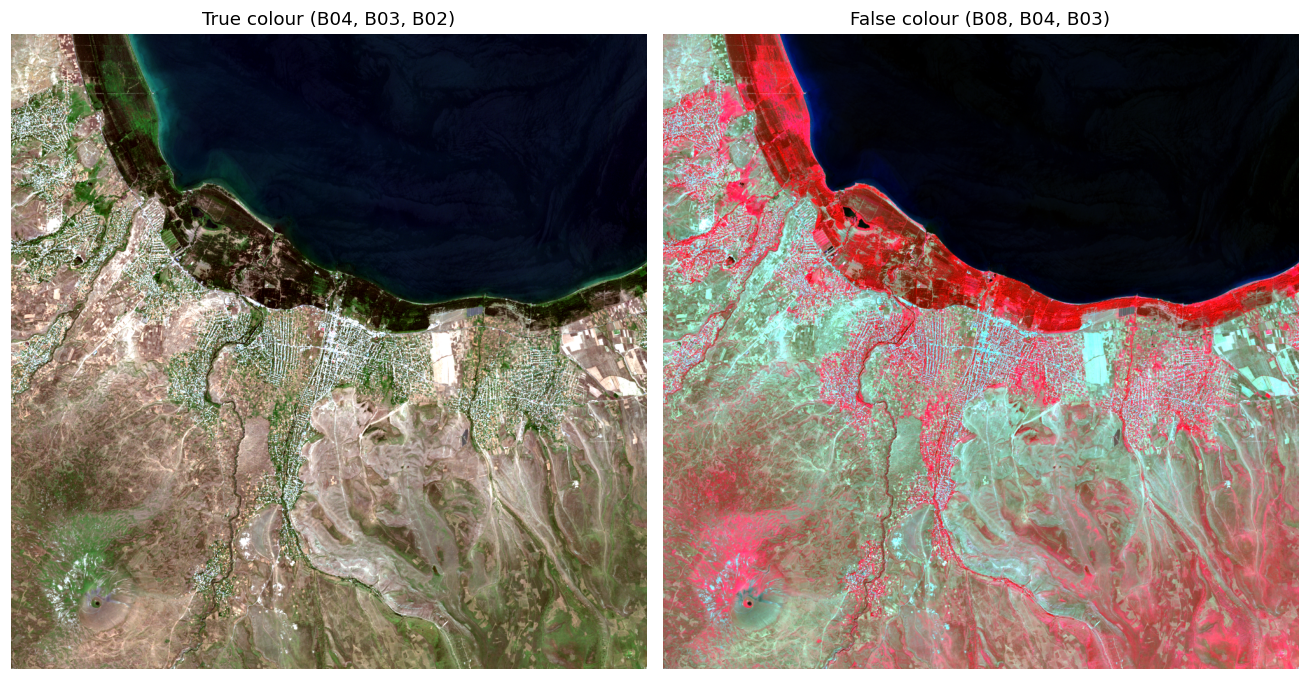

In [4]:
def stretch(a, lo=2, hi=98):
    """Percentile stretch to [0, 1], purely for display."""
    p_lo, p_hi = np.percentile(a, [lo, hi])
    return np.clip((a - p_lo) / (p_hi - p_lo), 0, 1)


idx = {c: i for i, c in enumerate(band_codes)}
true_colour = np.dstack([stretch(refl[:, :, idx["B04"]]),
                         stretch(refl[:, :, idx["B03"]]),
                         stretch(refl[:, :, idx["B02"]])])
false_colour = np.dstack([stretch(refl[:, :, idx["B08"]]),
                          stretch(refl[:, :, idx["B04"]]),
                          stretch(refl[:, :, idx["B03"]])])

fig, axes = plt.subplots(1, 2, figsize=(12, 6.2))
for ax, img, title in zip(axes, [true_colour, false_colour],
                          ["True colour (B04, B03, B02)", "False colour (B08, B04, B03)"]):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_true_false_colour.png", bbox_inches="tight")
plt.show()

### The answer in the back of the book

This particular patch of Armenia has already been mapped. ESA's **WorldCover** classifies the
whole planet at 10 m into 11 land-cover classes, and the labels for exactly these pixels ship in
the same npz, already reprojected onto our grid.

Look at it once now, so you know what is actually down there --- and then **put it away**.
Everything up to section 5 is done without it: we pick `k`, cluster, and name the groups as if it
did not exist, which is the honest situation in real unsupervised work. In section 5 we take it
back out and find out how we did.

It is not truth handed down from heaven either --- WorldCover is itself a model output, with its
own errors. But it is an **independent** opinion, which is more than clustering alone ever gives
you.


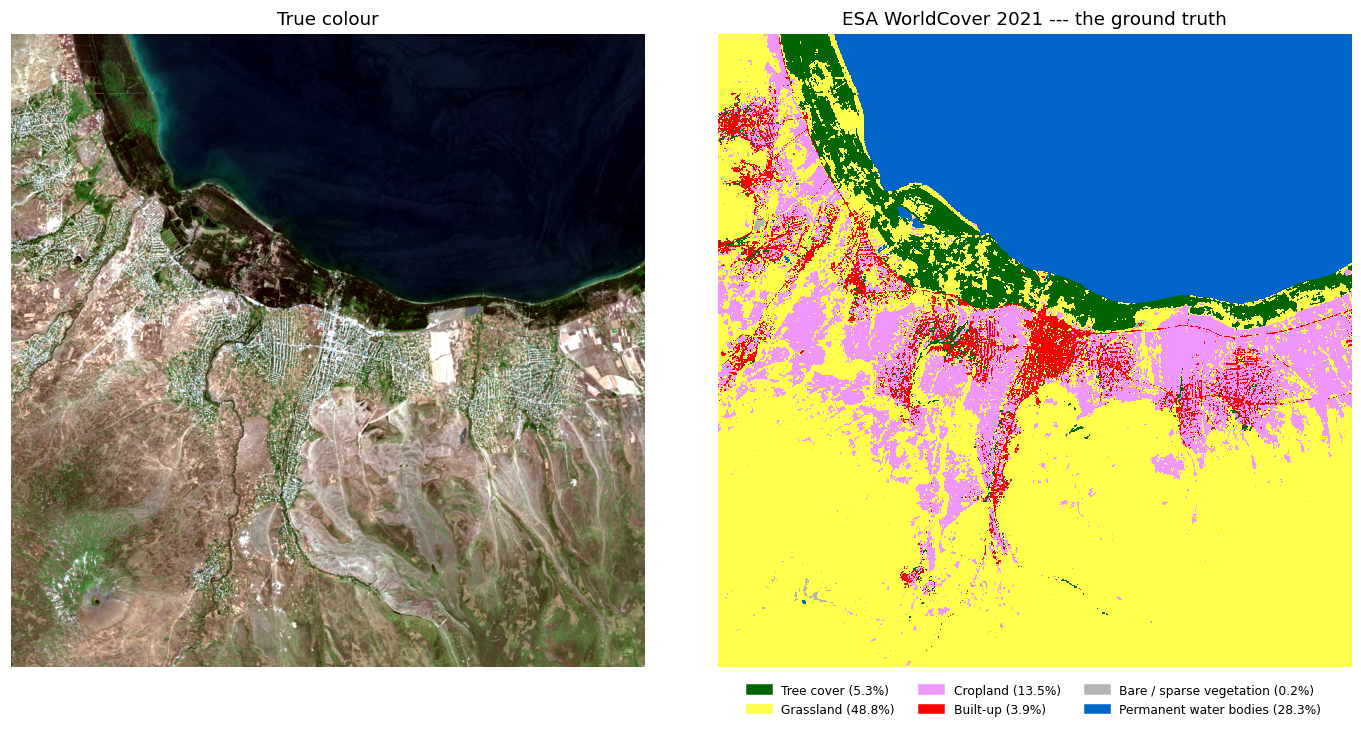

Grassland                  48.80%
Permanent water bodies     28.29%
Cropland                   13.47%
Tree cover                  5.25%
Built-up                    3.93%
Bare / sparse vegetation    0.24%
Herbaceous wetland          0.00%


In [5]:
# ESA WorldCover v200 official class colours
WC_COLOURS = {10: "#006400", 20: "#FFBB22", 30: "#FFFF4C", 40: "#F096FF",
              50: "#FA0000", 60: "#B4B4B4", 70: "#F0F0F0", 80: "#0064C8",
              90: "#0096A0", 95: "#00CF75", 100: "#FAE6A0"}

wc_map = data["worldcover"]
wc_all_names = {int(c): str(n) for c, n in zip(data["worldcover_codes"], data["worldcover_names"])}

codes_present = np.unique(wc_map)                      # np.unique returns them sorted
shares = {int(c): float((wc_map == c).mean()) for c in codes_present}
wc_idx = np.searchsorted(codes_present, wc_map)        # remap codes to 0..n-1 for the colormap

fig, axes = plt.subplots(1, 2, figsize=(13, 6.4))
axes[0].imshow(true_colour)
axes[0].set_title("True colour")
axes[1].imshow(wc_idx, cmap=ListedColormap([WC_COLOURS[int(c)] for c in codes_present]),
               vmin=-0.5, vmax=len(codes_present) - 0.5, interpolation="nearest")
axes[1].set_title("ESA WorldCover 2021 --- the ground truth")
for ax in axes:
    ax.axis("off")
# only classes with a visible footprint earn a legend entry; the rest still colour the map
legend_codes = [int(c) for c in codes_present if shares[int(c)] >= 0.001]
handles = [plt.Rectangle((0, 0), 1, 1, color=WC_COLOURS[c]) for c in legend_codes]
axes[1].legend(handles, [f"{wc_all_names[c]} ({shares[c]:.1%})" for c in legend_codes],
               loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_worldcover.png", bbox_inches="tight")
plt.show()

for c in sorted(shares, key=lambda c: -shares[c]):
    if shares[c] >= 1e-5:
        print(f"{wc_all_names[c]:26s} {shares[c]:6.2%}")


## 1. From an image to a table

Clustering does not know about images. Flatten `(H, W, 6)` into `(H*W, 6)` and every row is one
pixel: **400 m² of Armenia described by six numbers**. The spatial arrangement is thrown away
entirely --- the algorithm never learns that two pixels are neighbours. We get the map back at
the end only because we kept the row order and can reshape the labels.

In [6]:
X = refl.reshape(-1, B)
print(f"table: {X.shape[0]:,} pixels x {X.shape[1]} bands")

table: 1,000,000 pixels x 6 bands


### Should we scale?

The deck says *scale first*, and the reason is that k-means measures plain Euclidean distance,
so a feature with a wide spread quietly counts for more than one with a narrow spread. Look at
the standard deviations printed above: near-infrared and short-wave infrared swing about
**five times** as wide as blue. Unscaled, they dominate.

But "dominate" is not the same as "distort". These six features are all reflectance, in the same
unit, on the same instrument. Rather than assume, we will run it both ways and come back with a
measurement in section 5. Keep both versions.

In [7]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print("standard deviation per band")
print(f"{'band':6s} {'raw':>10s} {'scaled':>10s}")
for i, code in enumerate(band_codes):
    print(f"{code:6s} {X[:, i].std():10.4f} {Xs[:, i].std():10.4f}")

standard deviation per band
band          raw     scaled
B02        0.0195     1.0000
B03        0.0262     1.0000
B04        0.0414     1.0000
B08        0.1090     1.0000
B11        0.1136     1.0000
B12        0.0779     1.0000


## 2. k-means, and naming what comes out

### How many clusters?

Two diagnostics from the lecture. k-means is fitted on a **100 000**-pixel subsample; the
silhouette is computed on a smaller **10 000**-pixel one, because it compares every pair of
points, so it is O(n²) and even 100 000 would be out of reach.

In [8]:
sub = rng.choice(X.shape[0], 100_000, replace=False)
sil_sub = rng.choice(X.shape[0], 10_000, replace=False)

k_values = list(range(2, 13))
inertia, silhouette = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit(Xs[sub])
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(Xs[sil_sub], km.predict(Xs[sil_sub])))
    print(f"k={k:2d}  inertia {km.inertia_:12,.0f}   silhouette {silhouette[-1]:.3f}")

k= 2  inertia      177,462   silhouette 0.679


k= 3  inertia      102,825   silhouette 0.542


k= 4  inertia       71,364   silhouette 0.532


k= 5  inertia       53,369   silhouette 0.530


k= 6  inertia       43,844   silhouette 0.497


...

k= 8  inertia       34,874   silhouette 0.471


k= 9  inertia       31,926   silhouette 0.453


k=10  inertia       29,583   silhouette 0.456


k=11  inertia       27,297   silhouette 0.451


k=12  inertia       25,876   silhouette 0.438


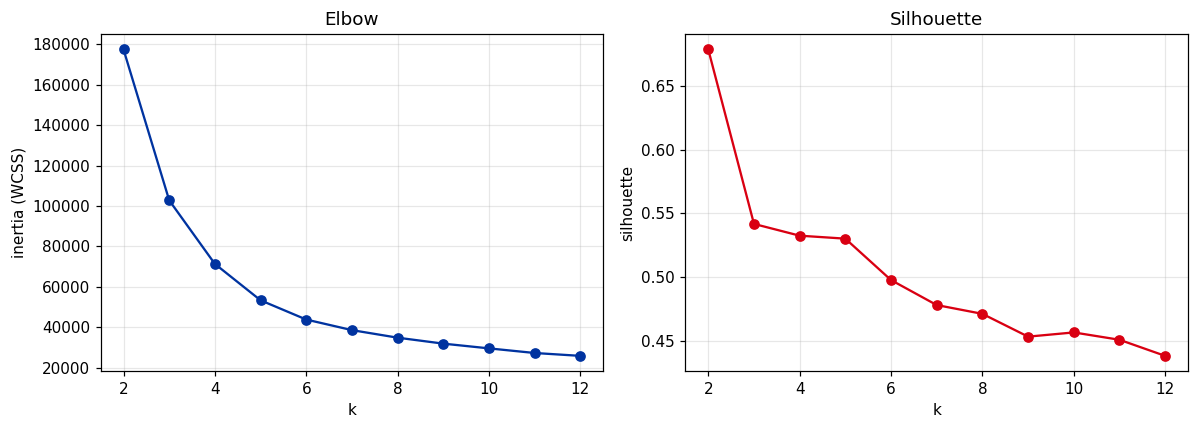

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(k_values, inertia, "o-", color=ARM_BLUE)
axes[0].set(xlabel="k", ylabel="inertia (WCSS)", title="Elbow")
axes[1].plot(k_values, silhouette, "o-", color=ARM_RED)
axes[1].set(xlabel="k", ylabel="silhouette", title="Silhouette")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_elbow_silhouette.png", bbox_inches="tight")
plt.show()

**They disagree, and the disagreement is informative.**

The silhouette is highest at `k=2` and falls from there. It is not malfunctioning: there really
is one split in this scene that is cleaner than every other, **water against everything else**,
and a metric that rewards tight, well-separated clusters will always prefer to stop there.

The elbow flattens out somewhere around `k=4` to `k=5`. That is the more useful reading, because
we are not looking for the single cleanest cut --- we are looking for land-cover types, and we
can see from the false-colour image that there are more than two. We take **k = 5** and,
unusually for clustering, we will get to find out in section 5 whether that was the right call.

In [10]:
K = 5
km = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit(Xs)
labels = km.labels_
label_map = labels.reshape(H, W)

sizes = np.bincount(labels) / labels.size
for c in range(K):
    print(f"cluster {c}: {sizes[c]:6.1%} of the scene")

cluster 0:  26.8% of the scene
cluster 1:  28.2% of the scene
cluster 2:  32.0% of the scene
cluster 3:   4.9% of the scene
cluster 4:   8.1% of the scene


### The naming step

This is the part the image-compression practical never had. A cluster centre here is a **mean
spectrum**: what this kind of ground does to light at six wavelengths. Three shapes are enough
to read the whole scene:

- **water** absorbs almost everything past red, so its curve collapses towards zero in the
  infrared,
- **living vegetation** reflects near-infrared strongly while absorbing red for photosynthesis,
  giving a sharp step up between B04 and B08,
- **bare ground and built surfaces** reflect steadily more towards longer wavelengths, so the
  curve rises gently all the way across with no step.

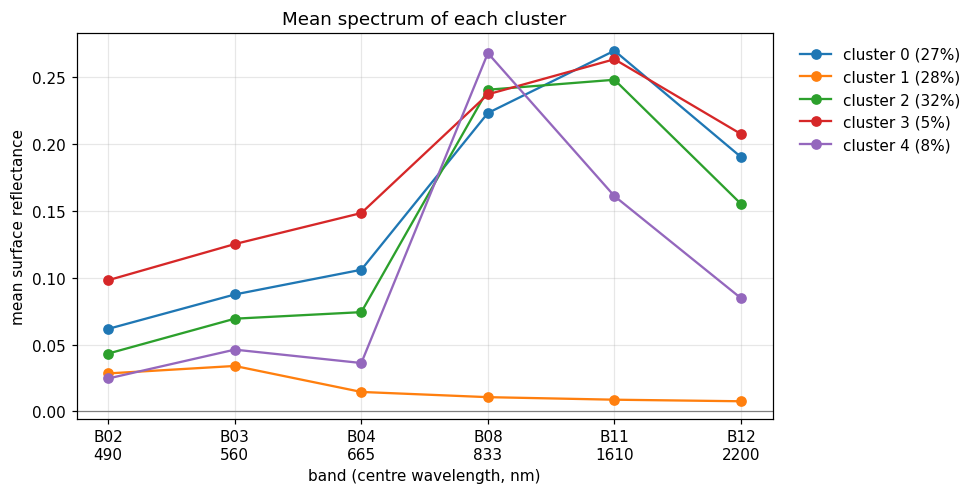

 cluster      B02      B03      B04      B08      B11      B12    NIR-red step
       0    0.062    0.087    0.106    0.223    0.270    0.190    +0.117
       1    0.028    0.034    0.015    0.011    0.009    0.008    -0.004
       2    0.043    0.069    0.074    0.241    0.248    0.155    +0.166
       3    0.098    0.125    0.148    0.237    0.263    0.207    +0.089
       4    0.025    0.046    0.036    0.268    0.161    0.085    +0.232


In [11]:
centres = np.array([X[labels == c].mean(axis=0) for c in range(K)])

# Bands are plotted evenly spaced rather than at true wavelength: the visible bands sit within
# 175 nm of each other and would pile up on the left, hiding the red-to-infrared step.
fig, ax = plt.subplots(figsize=(9, 4.6))
palette = plt.get_cmap("tab10")(np.arange(K))
for c in range(K):
    ax.plot(range(B), centres[c], "o-", color=palette[c], label=f"cluster {c} ({sizes[c]:.0%})")
ax.set(xlabel="band (centre wavelength, nm)", ylabel="mean surface reflectance",
       title="Mean spectrum of each cluster")
ax.set_xticks(range(B), [f"{c}\n{WAVELENGTH[c]}" for c in band_codes])
ax.axhline(0, color="grey", lw=0.8)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_cluster_spectra.png", bbox_inches="tight")
plt.show()

print(f"{'cluster':>8s} " + " ".join(f"{c:>8s}" for c in band_codes) + "    NIR-red step")
for c in range(K):
    step = centres[c][idx["B08"]] - centres[c][idx["B04"]]
    print(f"{c:>8d} " + " ".join(f"{v:8.3f}" for v in centres[c]) + f"    {step:+.3f}")

Read the table rather than guessing: the cluster whose infrared reflectance is lowest is water;
the one with the largest jump from red to near-infrared is the greenest vegetation; the one
that is brightest everywhere is bare and built surface.

In [12]:
nir_level = centres[:, idx["B08"]]
nir_red_step = centres[:, idx["B08"]] - centres[:, idx["B04"]]
brightness = centres.mean(axis=1)

order_veg = np.argsort(-nir_red_step)
water_c = int(np.argmin(nir_level))
bright_c = int(np.argmax(brightness))
veg_c = int(order_veg[0]) if order_veg[0] != water_c else int(order_veg[1])

print(f"lowest infrared      -> cluster {water_c}  = water")
print(f"largest red->NIR step-> cluster {veg_c}  = densest vegetation")
print(f"brightest overall    -> cluster {bright_c}  = bare / built")

lowest infrared      -> cluster 1  = water
largest red->NIR step-> cluster 4  = densest vegetation
brightest overall    -> cluster 3  = bare / built


Names, assigned by hand from those spectra. This is a judgement call and it is supposed to be:
the algorithm found the groups, a human decides what they are.

In [13]:
CLUSTER_NAMES = {}
rank_by_step = list(np.argsort(-nir_red_step))
rank_by_step.remove(water_c)
if bright_c in rank_by_step:
    rank_by_step.remove(bright_c)

CLUSTER_NAMES[water_c] = "water"
CLUSTER_NAMES[bright_c] = "bare / built-up"
descriptors = ["dense vegetation", "mixed vegetation", "dry / sparse vegetation"]
for name, c in zip(descriptors, rank_by_step):
    CLUSTER_NAMES[int(c)] = name

SEMANTIC = {"water": "#1f4e9c", "dense vegetation": "#1a7a1a", "mixed vegetation": "#7cb342",
            "dry / sparse vegetation": "#c9b458", "bare / built-up": "#b0553a"}
colours = [SEMANTIC[CLUSTER_NAMES[c]] for c in range(K)]

for c in range(K):
    print(f"cluster {c}  {sizes[c]:6.1%}  {CLUSTER_NAMES[c]}")

cluster 0   26.8%  dry / sparse vegetation
cluster 1   28.2%  water
cluster 2   32.0%  mixed vegetation
cluster 3    4.9%  bare / built-up
cluster 4    8.1%  dense vegetation


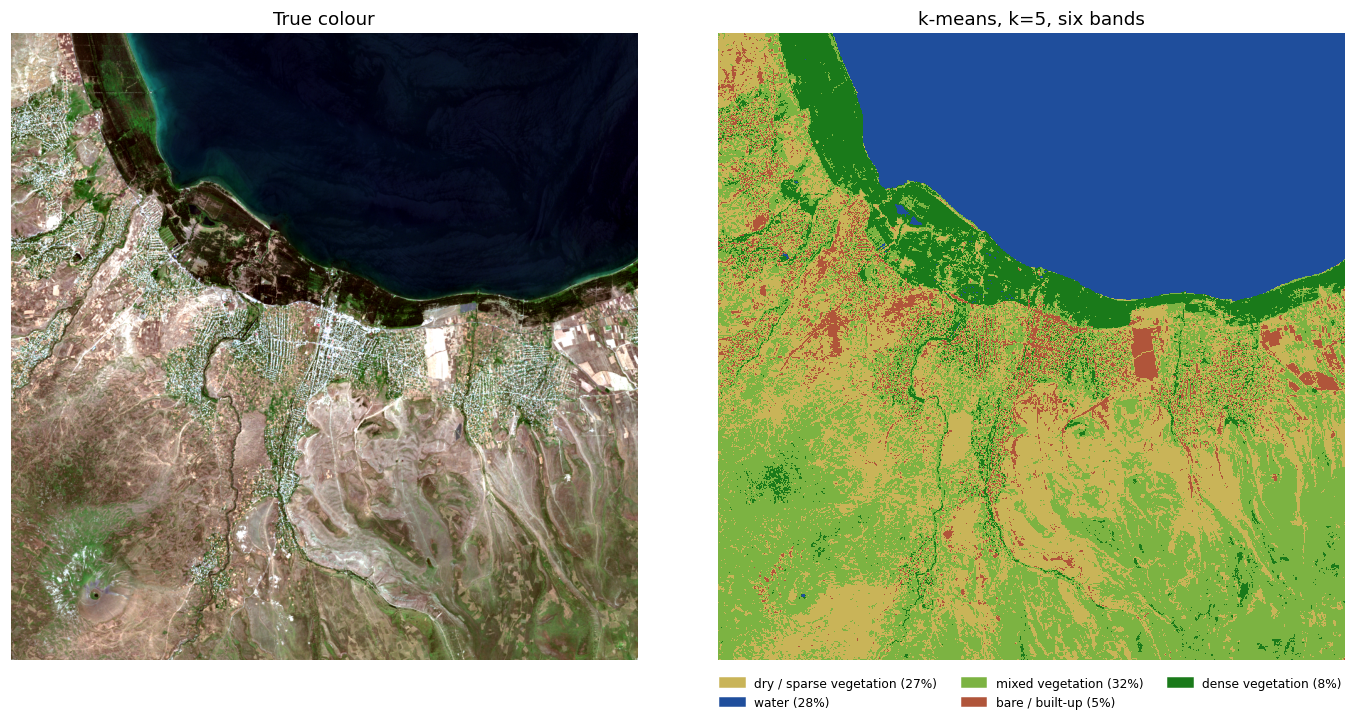

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6.4))
axes[0].imshow(true_colour)
axes[0].set_title("True colour")
axes[1].imshow(label_map, cmap=ListedColormap(colours), vmin=-0.5, vmax=K - 0.5, interpolation="nearest")
axes[1].set_title(f"k-means, k={K}, six bands")
for ax in axes:
    ax.axis("off")
handles = [plt.Rectangle((0, 0), 1, 1, color=SEMANTIC[CLUSTER_NAMES[c]]) for c in range(K)]
axes[1].legend(handles, [f"{CLUSTER_NAMES[c]} ({sizes[c]:.0%})" for c in range(K)],
               loc="upper center", bbox_to_anchor=(0.5, -0.01), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_kmeans_map.png", bbox_inches="tight")
plt.show()

## 3. Representation is the model

We fed the algorithm raw reflectance. Remote sensing rarely does, and the reason is worth spelling
out properly.

### Why a ratio beats a level

Picture the same grass twice: once on a slope facing the sun, once on a slope facing away. The
material is identical, but the sunlit one returns more light **in every band**, so all six of its
numbers are larger. In spectral space those two pixels sit far apart, strung out along a line from
the origin --- and k-means, which knows nothing but Euclidean distance, will cheerfully put them in
different clusters. It will have clustered **illumination**, not land cover.

Now divide one band by another. Numerator and denominator scale up together, the brightness factor
cancels, and what survives is the **shape** of the spectrum --- which is the part that says what
the material actually is.

The standard form is the **normalised difference**, a ratio rearranged so it always lands in
$[-1, 1]$:

$$\text{ND}(A, B) = \frac{A - B}{A + B}$$

Feed it the pair of bands where the thing you care about has its sharpest contrast:

| Index | Definition | Reads out as |
|---|---|---|
| **NDVI** vegetation | $\dfrac{\text{NIR} - \text{red}}{\text{NIR} + \text{red}}$ | Live leaves reflect NIR hard and absorb red: dense vegetation ~0.6-0.9, dry grass ~0.3-0.5, bare soil ~0.1, water negative. |
| **NDWI** water | $\dfrac{\text{green} - \text{NIR}}{\text{green} + \text{NIR}}$ | Water absorbs NIR almost totally but still returns some green, so open water goes positive and essentially everything else negative. |
| **NDBI** built / bare | $\dfrac{\text{SWIR}_1 - \text{NIR}}{\text{SWIR}_1 + \text{NIR}}$ | Dry mineral surfaces reflect more SWIR than NIR; vegetation does the opposite. Positive over bare and built, negative over green. |

Every one is arithmetic **on the six columns we already have**. No new measurement, no new data.
That is the whole point of this section: we are not adding information, we are choosing which of
the information already present the distance function is allowed to see.


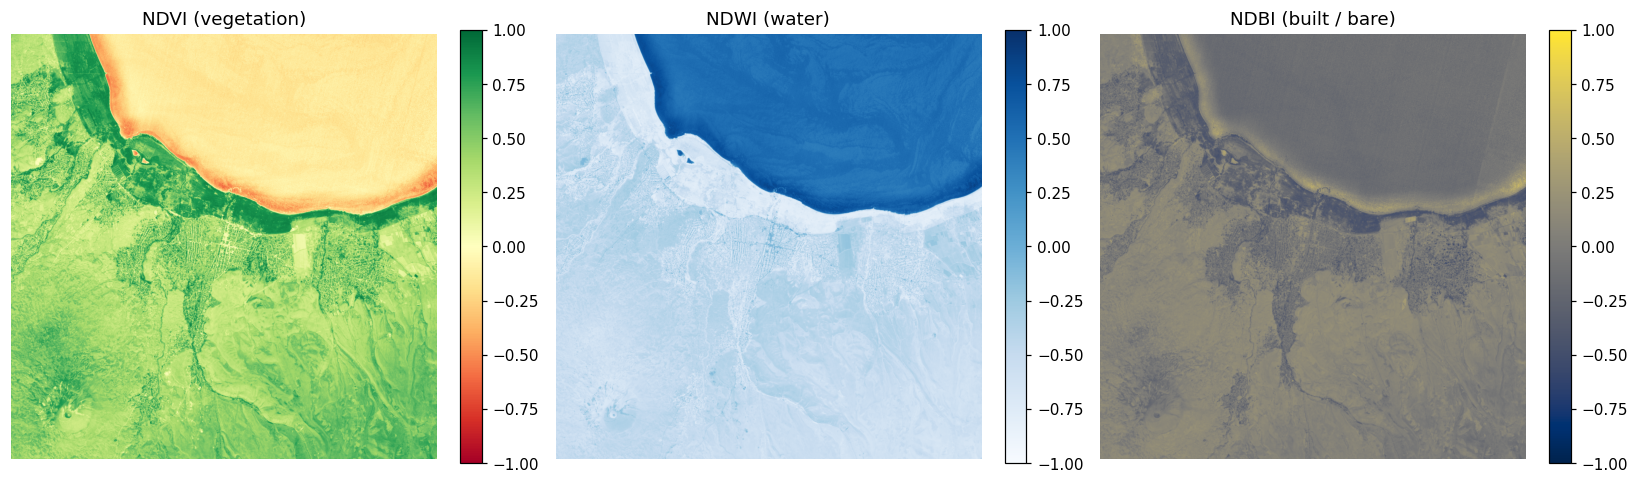

feature      std   (compare with the bands, roughly 0.02 to 0.11)
NDVI      0.318
NDWI      0.476
NDBI      0.139


In [15]:
c_refl = np.clip(refl, 0, None)
eps = 1e-6
ndvi = ((c_refl[:, :, idx["B08"]] - c_refl[:, :, idx["B04"]]) /
        (c_refl[:, :, idx["B08"]] + c_refl[:, :, idx["B04"]] + eps))
ndwi = ((c_refl[:, :, idx["B03"]] - c_refl[:, :, idx["B08"]]) /
        (c_refl[:, :, idx["B03"]] + c_refl[:, :, idx["B08"]] + eps))
ndbi = ((c_refl[:, :, idx["B11"]] - c_refl[:, :, idx["B08"]]) /
        (c_refl[:, :, idx["B11"]] + c_refl[:, :, idx["B08"]] + eps))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title, cmap in zip(axes, [ndvi, ndwi, ndbi],
                                ["NDVI (vegetation)", "NDWI (water)", "NDBI (built / bare)"],
                                ["RdYlGn", "Blues", "cividis"]):
    im = ax.imshow(img, cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_indices.png", bbox_inches="tight")
plt.show()

print(f"{'feature':6s} {'std':>8s}   (compare with the bands, roughly 0.02 to 0.11)")
for name, arr in [("NDVI", ndvi), ("NDWI", ndwi), ("NDBI", ndbi)]:
    print(f"{name:6s} {arr.std():8.3f}")

Note the spreads, and note that they are not uniform. NDVI and NDWI swing across most of
$[-1, 1]$: about **3 to 4 times** wider than the widest band and **16 to 24 times** wider than
the narrowest. NDBI is the exception --- at 0.139 it is barely wider than B11's 0.114.

So stacking NDVI and NDWI in beside the raw bands *unscaled* hands them control of every
distance k-means computes. Whether that domination helps or hurts is a question we can finally
answer with a number, in section 5.

Three feature sets, same `k`, and we compare the maps.

"**Indices only**" means literally that: the six reflectance columns are **thrown away**, and each
pixel is described by three numbers --- NDVI, NDWI, NDBI. Nothing new is measured, since all three
are computed from those same six bands; the table is simply 3 columns wide instead of 6, and every
column is now a brightness-independent *shape* descriptor rather than a level.

In [16]:
FEATURE_SETS = {
    "6 bands": X,
    "6 bands + NDVI + NDWI": np.column_stack([X, ndvi.reshape(-1), ndwi.reshape(-1)]),
    "indices only": np.column_stack([ndvi.reshape(-1), ndwi.reshape(-1), ndbi.reshape(-1)]),
}

maps = {}
for name, F in FEATURE_SETS.items():
    Fs = StandardScaler().fit_transform(F)
    lab = KMeans(n_clusters=K, n_init=10, random_state=SEED).fit_predict(Fs)
    maps[name] = lab.reshape(H, W)
    print(f"{name:24s} silhouette {silhouette_score(Fs[sil_sub], lab[sil_sub]):.3f}")

6 bands                  silhouette 0.530


6 bands + NDVI + NDWI    silhouette 0.529


indices only             silhouette 0.560


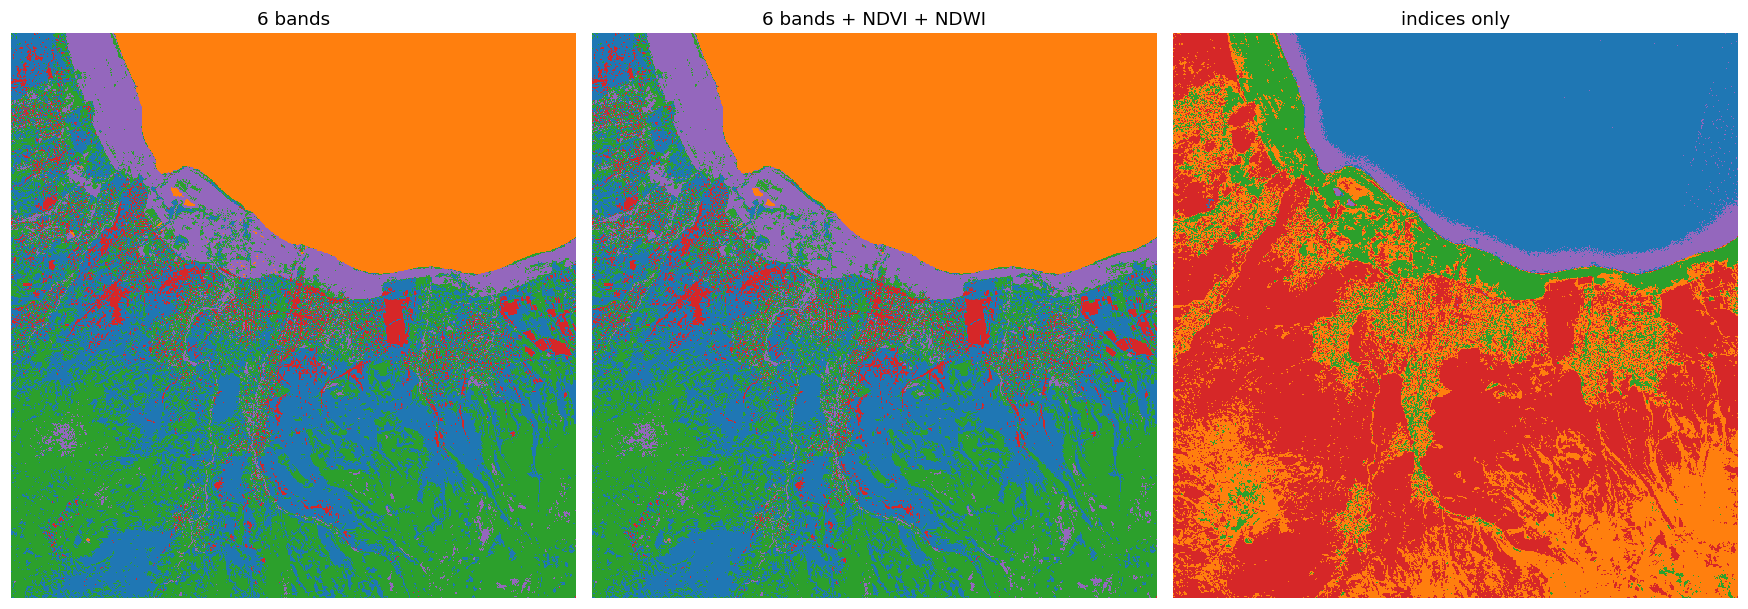

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, (name, m) in zip(axes, maps.items()):
    ax.imshow(m, cmap="tab10", vmin=-0.5, vmax=9.5, interpolation="nearest")
    ax.set_title(name)
    ax.axis("off")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_feature_sets.png", bbox_inches="tight")
plt.show()

Same algorithm, same `k`, same pixels, three different maps. Cluster **colours are arbitrary**
and will not correspond between panels --- compare the *boundaries*, not the hues.

There is no held-out score that can tell you which of these is right. In supervised learning the
validation set arbitrates; here nothing does. **Choosing the representation is the modelling
decision**, and you make it before you have any way to check it.


## 4. An honest failure: DBSCAN

Not every algorithm from the lecture fits this problem, and reporting one that did not work is
part of the job.

DBSCAN needs a neighbourhood radius `eps`. The lecture's recipe is to sort the distance to each
point's 10th nearest neighbour and look for the elbow.


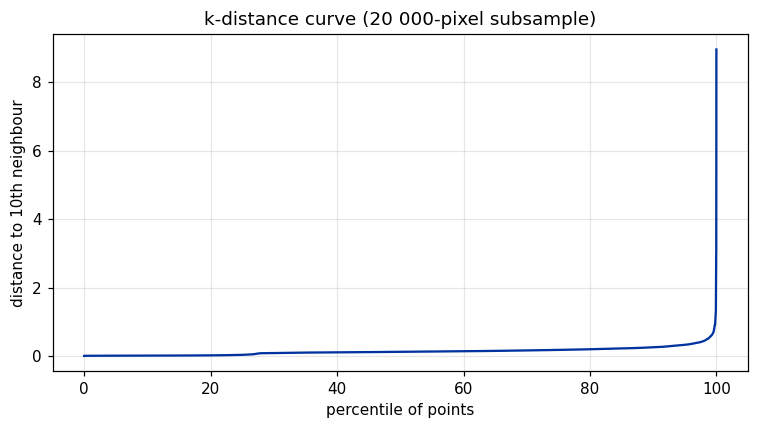

p50: 0.129
p75: 0.186
p90: 0.261
p95: 0.333
p99: 0.567


In [18]:
db_sub = rng.choice(X.shape[0], 20_000, replace=False)
nn = NearestNeighbors(n_neighbors=10).fit(Xs[db_sub])
kdist = np.sort(nn.kneighbors(Xs[db_sub])[0][:, -1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.linspace(0, 100, kdist.size), kdist, color=ARM_BLUE)
ax.set(xlabel="percentile of points", ylabel="distance to 10th neighbour",
       title="k-distance curve (20 000-pixel subsample)")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_kdistance.png", bbox_inches="tight")
plt.show()

for p in (50, 75, 90, 95, 99):
    print(f"p{p:>2d}: {np.percentile(kdist, p):.3f}")

In [19]:
rows = []
for eps_v in (0.15, 0.2, 0.25, 0.3, 0.4, 0.5):
    db = DBSCAN(eps=eps_v, min_samples=10).fit(Xs[db_sub])
    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    biggest = np.bincount(db.labels_[db.labels_ >= 0]).max() / db.labels_.size if n_clusters else 0
    rows.append((eps_v, n_clusters, (db.labels_ == -1).mean(), biggest))

print(f"{'eps':>6s} {'clusters':>9s} {'noise':>8s} {'largest cluster':>16s}")
for eps_v, n_c, noise, biggest in rows:
    print(f"{eps_v:6.2f} {n_c:9d} {noise:8.1%} {biggest:16.1%}")

   eps  clusters    noise  largest cluster
  0.15        20    27.4%            41.8%
  0.20        10    13.2%            58.2%
  0.25         5     6.7%            64.9%
  0.30         2     3.7%            68.0%
  0.40         3     1.4%            70.1%
  0.50         2     0.8%            70.9%


The elbow sits somewhere around 0.25 to 0.35, and that is precisely the range in which the
answer **falls apart**: a step of 0.1 in `eps` takes you from a double-figure number of clusters
to two, one of which holds almost every pixel. There is no plateau to stand on.

This is not a tuning failure, it is the wrong tool. DBSCAN looks for **dense regions separated
by sparse ones**, and spectral space here has no empty corridors --- ground cover varies
continuously, a field dries gradually into steppe, and the density just slopes. Add that at a
million pixels DBSCAN's neighbour graph is out of reach on a laptop, which is why we are
working on a 2 % subsample at all.

Reporting an algorithm that did not work is part of the job. The comparison table in the lecture
says DBSCAN is for arbitrary shapes with genuine density gaps and noise you want flagged. This
scene is none of those things.

## 5. The reckoning: ESA WorldCover

Everything so far was decided without labels, which is the honest situation. But this particular
patch of Armenia **has** been mapped: ESA's WorldCover product classifies the whole planet at
10 m into 11 classes, and it ships in the same npz, already on our pixel grid.

It is not truth handed down from heaven --- it is itself a model output, with its own errors ---
but it is an independent opinion, which is more than we have had so far.

In [20]:
wc = data["worldcover"].reshape(-1)
wc_names = {int(c): str(n) for c, n in zip(data["worldcover_codes"], data["worldcover_names"])}

present = pd.Series(wc).value_counts(normalize=True)
print("WorldCover classes in this crop")
for code, share in present.items():
    if share >= 0.0005:
        print(f"  {wc_names[int(code)]:26s} {share:6.1%}")

WorldCover classes in this crop
  Grassland                   48.8%
  Permanent water bodies      28.3%
  Cropland                    13.5%
  Tree cover                   5.3%
  Built-up                     3.9%
  Bare / sparse vegetation     0.2%


### Why accuracy is meaningless here

In [21]:
print(f"accuracy(worldcover_code, cluster_id) = {accuracy_score(wc, labels):.3f}")

accuracy(worldcover_code, cluster_id) = 0.000


**Zero.** Not "poor" --- exactly zero, because our clusters are numbered 0 to 4 and WorldCover's
classes are numbered 10, 30, 40, 50, 80, so not one pixel can ever agree. The lesson generalises
past this arithmetic accident: **cluster labels carry no identity**. Rerun k-means with a
different seed and the same partition comes back with the numbers permuted.

What we need is a metric that scores **which points were put together**, ignoring what the
groups are called. That is the Rand index, and its chance-adjusted form:

In [22]:
print(f"ARI (adjusted Rand)             : {adjusted_rand_score(wc, labels):.3f}")
print(f"AMI (adjusted mutual information): {adjusted_mutual_info_score(wc, labels):.3f}")

ARI (adjusted Rand)             : 0.484


AMI (adjusted mutual information): 0.545


### The scoreboard

Every choice we made along the way, now that we can grade them. Models are fit on the
100 000-pixel subsample and scored on all million pixels.

In [23]:
SCOREBOARD_SETS = {
    "RGB only (what the eye sees)": X[:, [idx["B02"], idx["B03"], idx["B04"]]],
    "6 bands": X,
    "6 bands + NDVI + NDWI": np.column_stack([X, ndvi.reshape(-1), ndwi.reshape(-1)]),
    "indices only": np.column_stack([ndvi.reshape(-1), ndwi.reshape(-1), ndbi.reshape(-1)]),
}

records = []
for name, F in SCOREBOARD_SETS.items():
    Fs = StandardScaler().fit_transform(F)
    for k in (4, 5, 6, 7):
        for scaled, matrix in (("scaled", Fs), ("raw", F)):
            model = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(matrix[sub])
            lab = model.predict(matrix)
            records.append({"features": name, "k": k, "scaling": scaled,
                            "ARI": adjusted_rand_score(wc, lab),
                            "AMI": adjusted_mutual_info_score(wc, lab)})

board = pd.DataFrame(records)
print(board.pivot_table(index=["features", "scaling"], columns="k", values="ARI").round(3))

k                                         4      5      6      7
features                     scaling                            
6 bands                      raw      0.479  0.447  0.417  0.422
                             scaled   0.464  0.483  0.446  0.430
6 bands + NDVI + NDWI        raw      0.443  0.400  0.381  0.363
                             scaled   0.478  0.479  0.443  0.427
RGB only (what the eye sees) raw      0.419  0.385  0.368  0.354
                             scaled   0.420  0.386  0.369  0.352
indices only                 raw      0.456  0.413  0.380  0.360
                             scaled   0.482  0.439  0.395  0.373


In [24]:
best_rows = board.sort_values("ARI", ascending=False).head(8)
print(best_rows.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

             features  k scaling   ARI   AMI
              6 bands  5  scaled 0.483 0.545
         indices only  4  scaled 0.482 0.535
6 bands + NDVI + NDWI  5  scaled 0.479 0.540
              6 bands  4     raw 0.479 0.543
6 bands + NDVI + NDWI  4  scaled 0.478 0.532
              6 bands  4  scaled 0.464 0.513
         indices only  4     raw 0.456 0.527
              6 bands  5     raw 0.447 0.525


Four things fall out of that table.

**Infrared is worth real accuracy.** RGB alone --- everything a camera sees --- is the worst
feature set at every single `k`, in both scalings, trailing the six-band model by 0.04 to 0.10
ARI. Section 0's claim, now with a number attached: the three infrared bands are not decoration.

**The representations tie, and that is the finding.** The top three configurations score 0.483,
0.482 and 0.479 --- six calibrated reflectance bands, three brightness-free ratios, and all nine
columns together, in a dead heat. The ratios really do cancel illumination, exactly as section 3
argued; it just buys nothing here, because illumination was not what was confusing k-means. What
separates a good row of this table from a bad one is **whether infrared is present at all**, not
how cleverly it is recombined. Feature engineering paid off in the sense that three columns match
six --- it did not beat them.

**Scaling behaves exactly as the lecture says.** Standardising helps at every single `k` on the
feature set whose spreads are most unequal --- bands plus NDVI and NDWI, a 24-fold range between
the narrowest and widest column --- and it helps a lot, +0.035 to +0.079 ARI. It does nothing at
all where the columns already share a unit: RGB moves by at most 0.002. The six bands, in between, move
between -0.015 and +0.036 depending on `k`. That is the `armred` trap stated precisely: **scaling
matters in proportion to how unequal the spreads were.** Six reflectance bands are already
commensurate, so it is nearly a no-op; bolt a $[-1, 1]$ index onto a $[0, 0.3]$ band and it is not.

**The silhouette was wrong about `k`, and cannot settle the features.** It said `k=2`; ARI peaks
at 4 or 5 in every row, which was the elbow's answer, not the silhouette's. On feature sets it
puts indices-only clearly top (0.560 against 0.530 and 0.529), where ARI has it level with the six
bands to within 0.001. That is not the silhouette lying so much as being asked an impossible
question: the real differences here are ~0.004 ARI, far below what any internal metric resolves.
An internal metric can tell you a partition is degenerate. It cannot referee a photo finish.


### Which classes did we merge?

ARI is one number. The contingency table says *where* the agreement came from.

In [25]:
ct = pd.crosstab(pd.Series([wc_names[int(v)] for v in wc], name="WorldCover"),
                 pd.Series([CLUSTER_NAMES[v] for v in labels], name="our cluster"),
                 normalize="index")
ct = ct.loc[[wc_names[int(c)] for c in present.index if present[c] >= 0.005]]
print((ct * 100).round(1).to_string())

our cluster             bare / built-up  dense vegetation  dry / sparse vegetation  mixed vegetation  water
WorldCover                                                                                                 
Grassland                           3.5               5.2                     38.4              52.9    0.0
Permanent water bodies              0.0               0.1                      0.0               0.1   99.7
Cropland                            9.6               4.4                     47.6              38.4    0.0
Tree cover                          0.3              93.1                      1.0               5.3    0.3
Built-up                           43.2               0.9                     38.4              17.5    0.0


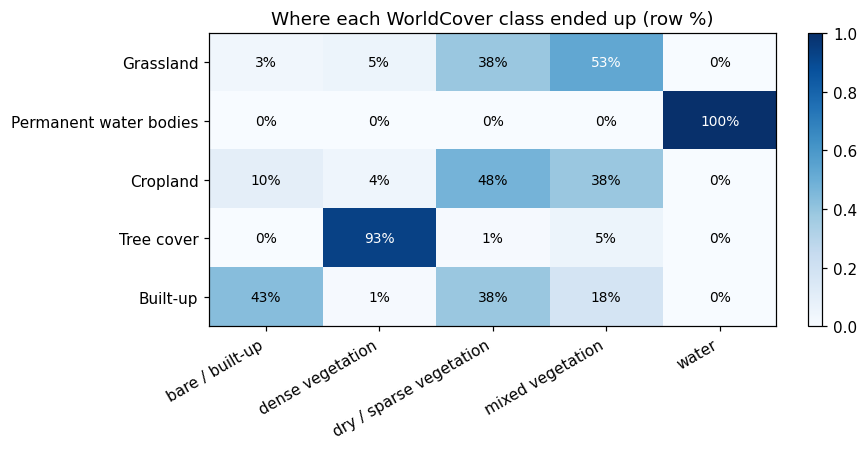

In [26]:
fig, ax = plt.subplots(figsize=(8, 4.2))
im = ax.imshow(ct.values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(ct.shape[1]), ct.columns, rotation=30, ha="right")
ax.set_yticks(range(ct.shape[0]), ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = ct.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                color="white" if v > 0.5 else "black", fontsize=9)
ax.set_title("Where each WorldCover class ended up (row %)")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/lc_contingency.png", bbox_inches="tight")
plt.show()

Water is essentially perfect. Let us put a number on it:

In [27]:
our_water = labels == water_c
their_water = wc == 80
print(f"our water cluster vs WorldCover water:")
print(f"  precision {(their_water & our_water).sum() / our_water.sum():.3f}")
print(f"  recall    {(their_water & our_water).sum() / their_water.sum():.3f}")

our water cluster vs WorldCover water:
  precision 0.999
  recall    0.997


Grassland and cropland, meanwhile, split across the same two vegetation clusters in almost
**mirrored proportions** --- whatever those two clusters are dividing, it is not the grass/crop
boundary. Built-up does not do much better: a plurality lands in "bare / built-up" and nearly as
much in the dry-vegetation cluster. Those two failures are different in kind and it is worth
separating them:

- **Built-up vs bare** is a resolution problem. At 20 m, a village of stone houses with dusty
  yards and a bare hillside genuinely return similar spectra. WorldCover separates them because
  it was trained with texture, context and time series, not one pixel in isolation.
- **Grassland vs cropland** is a definitional problem. There is no spectral boundary to find:
  the difference is *who planted it*, and land tenure does not reflect light. No clustering
  algorithm, at any resolution, on any feature set, will recover that distinction.


### How much of that ARI was just the lake?

One split in this scene is trivially easy, and it accounts for 28 % of the pixels. What happens
to the score if we take it away and cluster only the land?

In [28]:
land = labels != water_c
X_land = StandardScaler().fit_transform(X[land])

print(f"land is {land.mean():.1%} of the scene\n")
print(f"the k={K} model, scored on land pixels only : "
      f"{adjusted_rand_score(wc[land], labels[land]):.3f}")
for k in (3, 4, 5):
    lab_land = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_land)
    print(f"refit on land only, k={k}                   : "
          f"ARI {adjusted_rand_score(wc[land], lab_land):.3f}  "
          f"AMI {adjusted_mutual_info_score(wc[land], lab_land):.3f}")

land is 71.8% of the scene



the k=5 model, scored on land pixels only : 0.155


refit on land only, k=3                   : ARI 0.186  AMI 0.182


refit on land only, k=4                   : ARI 0.148  AMI 0.198


refit on land only, k=5                   : ARI 0.129  AMI 0.195


**This is the most important result in the notebook.**

An ARI near 0.5 looked respectable. Almost all of it was the lake. Take the water away and the
score collapses to a third of what it was, and refitting on land alone barely rescues it ---
a little at `k=3`, nothing at all beyond that.

Nothing went wrong. The clustering is doing exactly what it did before. What changed is that we
stopped grading it on a question with an obvious answer. **An aggregate score over an unbalanced
problem is mostly a report on the easy part**, and clustering has no held-out set, no baseline
and no convention to protect you from that. You have to go looking for it deliberately.

## Conclusion

Six bands, a million pixels, no labels, and a usable land-cover map of the south shore of Sevan.
The lecture's parts all showed up and several of them behaved differently from the slide:

| From the lecture | What this scene did with it |
|---|---|
| Scale first | Held up. Worth +0.08 ARI where column spreads differed 24-fold, worth 0.001 where they already matched. |
| Representation | Three very different feature sets finished within 0.004 ARI. Having infrared at all mattered; recombining it did not. |
| Elbow vs silhouette | Disagreed. The silhouette said `k=2` and was wrong; the elbow's 4-to-5 range is where ARI actually peaks. |
| DBSCAN | Failed, for a stateable reason: no density gaps, and O(n²) at this scale. |
| Accuracy vs ARI | Accuracy was exactly 0.000 while the partition was largely right. |
| Internal vs external metrics | The internal metric picked the wrong `k`; only the external one caught it. |
| Clustering is treacherous | An ARI of ~0.5 turned out to be mostly one easy split worth 28 % of the pixels. |

And the honest summary of what we built: it separates **water, vegetation and bare ground** very
well, it cannot tell a wheat field from a meadow, and it never could have, because that
difference is not in the light.